Bronze Assignment

1. Problem Statement
A company wants to predict **employee productivity scores** to improve workforce planning and training programs. You are hired as a Data Scientist to build a multivariate linear regression model that predicts an employee’s Productivity Score based on multiple work-related factors.
**Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score**
2,40,38,3,62
5,60,42,6,78
1,20,35,2,55
8,80,45,8,88
4,50,40,5,72
10,90,48,9,92
3,30,37,4,65
6,70,44,7,82
7,75,46,7,85
2,25,36,3,60.

** Interpretation **
> 1. Which factor most strongly impacts productivity?  
2. How does training affect productivity?  
3. Should the company increase training hours or working hours?  
4. What happens if Working Hours increase beyond optimal limits?  
5. Can productivity ever decrease with more experience?  
6. How would you detect overfitting in this model?  
7. Suggest one new feature to improve prediction accuracy.  

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from matplotlib import pyplot as plt

In [ ]:
data = {
    "Experience": [2,5,1,8,4,10,3,6,7,2],
    "Training_Hours": [40,60,20,80,50,90,30,70,75,25],
    "Working_Hours": [38,42,35,45,40,48,37,44,46,36],
    "Projects": [3,6,2,8,5,9,4,7,7,3],
    "Productivity_Score": [62,78,55,88,72,92,65,82,85,60]
}

df = pd.DataFrame(data)

In [ ]:
df.head()

,Experience,Training_Hours,Working_Hours,Projects,Productivity_Score
0,2,40,38,3,62
1,5,60,42,6,78
2,1,20,35,2,55
3,8,80,45,8,88
4,4,50,40,5,72


In [ ]:
X = df[['Experience', 'Training_Hours', 'Working_Hours', 'Projects']]
y = df['Productivity_Score']

In [ ]:
X.shape, y.shape

((10, 4), (10,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train.shape, X_test.shape

((8, 4), (2, 4))

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

print("Actual Productivity Scores:")
print(y_test.values)

print("\nPredicted Productivity Scores:")
print(y_pred)

Actual Productivity Scores:
[85 78]

Predicted Productivity Scores:
[81.04275534 76.93586698]


In [ ]:
r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, model.predict(X_train))
print("R2_test Score:", r2_test)
print("R2_train Score:", r2_train)

R2_test Score: 0.3146055370935623
R2_train Score: 0.9999147875547224


In [ ]:
y_pred_all = model.predict(X)
y_pred_train = model.predict(X_train)
print("R2 on full dataset:", r2_score(y, y_pred_all))
print("R2 on train dataset:", r2_score(y_train, y_pred_train))

R2 on full dataset: 0.9887808224878962
R2 on train dataset: 0.9999147875547224


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

          Feature  Coefficient
0      Experience    -0.263658
1  Training_Hours     0.272684
2   Working_Hours    -1.085511
3        Projects     4.885986


In [ ]:
df.corr()

,Experience,Training_Hours,Working_Hours,Projects,Productivity_Score
Experience,1.000000,0.969810,0.973178,0.988194,0.981991
Training_Hours,0.969810,1.000000,0.993132,0.977151,0.987045
Working_Hours,0.973178,0.993132,1.000000,0.974701,0.985684
Projects,0.988194,0.977151,0.974701,1.000000,0.995696
Productivity_Score,0.981991,0.987045,0.985684,0.995696,1.000000


**Ans 1 .** Which factor most strongly impacts productivity?  

> If we see model's coefficients Project's coefficient: 4.89 is the highest. Hence, number of projects completed has the strongest impact on productivity.

**Ans 2.** How does training affect productivity?    
> Every additional training hour increases productivity by 0.27 points.  

**Ans 3.**
> Should the company increase training hours or working hours?  
Both training hours and working hours are equally increasing the productivity training correlation with productivity is ~0.99 and working hour's correlation is also ~0.99.  

> Looking at coefficients, working hours has negative coefficient but it is likely due to multicollinearity, since all features are highly correlated.So, we should not consider this number for evaluation. In real life working more then optimal hours can increase fatigue hence can reduce productivity. While, traing hours almost always increase productivity.   

**Ans 4.** What happens if Working Hours increase beyond optimal limits?  
> The correlation shows a strong positive relationship between working hours and productivity ≈ 0.98, indicating that productivity increases as working hours increase. However, the regression coefficient appears negative due to multicollinearity between working hours, training hours, and projects.   
The dataset itself does not provide evidence that productivity decreases after an optimal number of working hours, but in real world scenarios excessive working hours may reduce productivity due to fatigue.

**Ans 5.** Can productivity ever decrease with more experience?  
> In real world or generally talking, productivity increases with experience. Correlation between productivity and experience shows 0.98 which states that productivity increases with experience. the -ve coefficient is because of multicollinearity. Since all the features are putting similar effect on output, model finds hard to find correct contribution.  

**Ans 6.** How would you detect overfitting in this model?  
> When model works well on training data but not well in testing data, it overfits.  
R2 Score for test data: 0.3146055370935623.
R2 Score on train dataset: 0.9999147875547224.

**Ans 7.** Suggest one new feature to improve prediction accuracy.
> Satisfaction score between 1-10. More satisfied, more productivity.


**2. Problem Statement**

A financial institution wants to predict whether a customer will default on a loan before approving it. Early identification of risky customers helps reduce financial loss.
You are working as a Machine Learning Analyst and must build a classification model using the **K-Nearest Neighbors (KNN) algorithm** to predict loan default.
This case introduces:
Mixed feature types
Financial risk interpretation
**Class imbalance awareness**
**Age,AnnualIncome(lakhs),CreditScore(300-900), LoanAmount(lakhs), LoanTerm(years), EmploymentType, loan(yes/no) **
28,6.5,720,5,5,Salaried,0  
45,12,680,10,10,Self-Employed,1  
35,8,750,6,7,Salaried,0  
50,15,640,12,15,Self-Employed,1  
30,7,710,5,5,Salaried,0  
42,10,660,9,10,Salaried,1  
26,5.5,730,4,4,Salaried,0  
48,14,650,11,12,Self-Employed,1  
38,9,700,7,8,Salaried,0  
55,16,620,13,15,Self-Employed,1  

Interpretation
1. Identify high-risk customers.  
2. What patterns lead to loan default?  
3. How do credit score and income influence predictions?  
4. Suggest banking policies based on model output.  
5. Compare KNN with Decision Trees for this problem.  
6. What happens if LoanAmount dominates distance calculation?  
7. Should KNN be used in real-time loan approval systems?  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

# Model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
data = {
    "Age": [28,45,35,50,30,42,26,48,38,55],
    "AnnualIncome": [6.5,12,8,15,7,10,5.5,14,9,16],
    "CreditScore": [720,680,750,640,710,660,730,650,700,620],
    "LoanAmount": [5,10,6,12,5,9,4,11,7,13],
    "LoanTerm": [5,7,7,15,5,10,4,12,8,15],
    "EmploymentType": ["Salaried","Self-Employed","Salaried","Self-Employed","Salaried",
                       "Salaried","Salaried","Self-Employed","Salaried","Self-Employed"],
    "LoanDefault": [0,1,0,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

In [ ]:
print(df.head())
print("============================")
print(df.info())
print("============================")
print(df.describe())
print("============================")
print(df['LoanDefault'].value_counts())


   Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm EmploymentType  \
0   28           6.5          720           5         5       Salaried   
1   45          12.0          680          10         7  Self-Employed   
2   35           8.0          750           6         7       Salaried   
3   50          15.0          640          12        15  Self-Employed   
4   30           7.0          710           5         5       Salaried   

   LoanDefault  
0            0  
1            1  
2            0  
3            1  
4            0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             10 non-null     int64  
 1   AnnualIncome    10 non-null     float64
 2   CreditScore     10 non-null     int64  
 3   LoanAmount      10 non-null     int64  
 4   LoanTerm        10 non-null     int64  
 5   EmploymentType  10 non-null     

`Employee type is of object datatype and needs to be changed to int/float`  

`Loan default value tells that dataset is balanced for LoanDefault values`

In [ ]:
le = LabelEncoder()
df["EmploymentType"] = le.fit_transform(df["EmploymentType"])
print(df.head())

   Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm  EmploymentType  \
0   28           6.5          720           5         5               0   
1   45          12.0          680          10         7               1   
2   35           8.0          750           6         7               0   
3   50          15.0          640          12        15               1   
4   30           7.0          710           5         5               0   

   LoanDefault  
0            0  
1            1  
2            0  
3            1  
4            0  


In [ ]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'Salaried': np.int64(0), 'Self-Employed': np.int64(1)}


Salaried = 0  
Self_employed = 1

In [ ]:
X = df.drop("LoanDefault", axis=1)
y = df["LoanDefault"]
print(X.shape)
print(y.shape)

(10, 6)
(10,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)

(8, 6)
(8,)


In [ ]:
# Credit score numbers are too large and it will dominate if not scaled. hence using
# standard scaler.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaled Training Data:")
print(X_train[:5])

Scaled Training Data:
[[ 0.26624161 -0.06401844 -0.55555556  0.26252051  0.20704985 -0.77459667]
 [-1.08917021 -0.9602766   0.77777778 -0.93757325 -0.97609216 -0.77459667]
 [ 0.84713238  0.9602766  -0.77777778  0.86256739  0.68030666  1.29099445]
 [-0.4114643  -0.57616596  1.44444444 -0.63754981 -0.50283536 -0.77459667]
 [ 1.52483829  1.47242412 -1.44444444  1.46261427  1.39019186  1.29099445]]


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
print("KNN Model trained successfully!")

KNN Model trained successfully!


In [ ]:
y_pred = knn_model.predict(X_test)

In [ ]:
y_pred

array([0, 1])

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



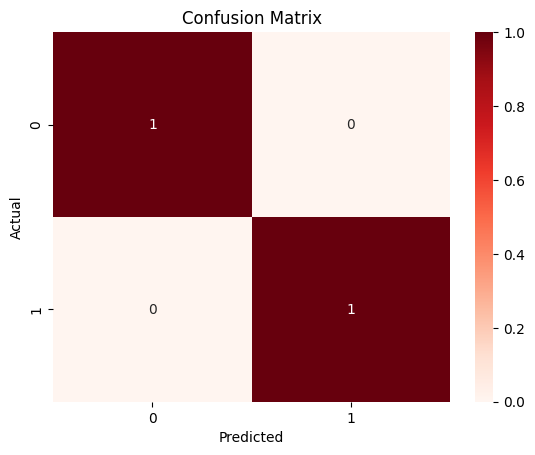

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
#score is accuracy here
cr = classification_report(y_test, y_pred)
print("\nClassification Report:\n", cr)

# Optional: visualize confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

`Accuracy`
> considers all correct predictions (both correctly identified positives and correctly identified negatives) relative to all instances.

`Confusion Matrix`
>shows True Positives, False Positives, True Negatives, False Negatives
>Example:
>[[TN FP]
> [FN TP]]  

`Classification Report`
>**Precision** How many of predicted defaultswere actually defaults?

>**Recall** of actual defaults, how many did model catch?

>**F1-score**  The F1-score is the harmonic mean of precision and recall.

>**score**  The score is the accuracy.


## Interpretation

In [ ]:
high_risk = df[df["LoanDefault"] == 1]
print(high_risk)

   Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm  EmploymentType  \
1   45          12.0          680          10         7               1   
3   50          15.0          640          12        15               1   
5   42          10.0          660           9        10               0   
7   48          14.0          650          11        12               1   
9   55          16.0          620          13        15               1   

   LoanDefault  
1            1  
3            1  
5            1  
7            1  
9            1  


**Ans 1.**  Identify High-Risk Customers   
>high_risk customers are defaulters, predicted as 1
   
**Ans 2.** What patterns lead to loan default?  
> In Knn, no weights are assigned to features, We can use Permutation Importance library **eli5** to see how change in a feature affects the prediction (small dataset so not effective). It works by shuffling a feature and measuring how much model accuracy drops.   
|Weight|	Feature|
|------|---------|  
|0.1000 ± 0.4000|	EmploymentType  |
|0 ± 0.0000|	LoanTerm  |
|0 ± 0.0000|	LoanAmount |
|0 ± 0.0000|	CreditScore |
|0 ± 0.0000|	AnnualIncome |
|0 ± 0.0000|	Age |

OR.  
By inspecting the dataset it is visible that low credic scor leads to loan default.  

**Ans 3.** How do credit score and income influence predictions?  
> I used scatterplot to check. **Higher credit score:** Non default(low risk) and **less credit score:** defaulter(high risk).  
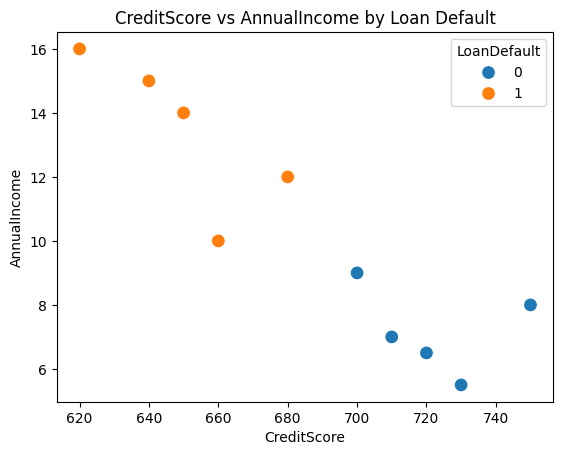  

**Ans 4.** Suggest banking policies based on model output.  
> Since the dataset is small, here I will not consider feature's permutation importance to create policy. But banks can use prediction and create a score rubric (using thresholds) after screening the dataset.  

>1. Rubric score table can look like below:

>| Feature              | Risk Points |
>| -------------------- | ----------- |
>| CreditScore < 660    | 2           |
>| LoanAmount > 9 lakhs | 2           |
>| LoanTerm > 10 years  | 1           |
>| Self-Employed        | 1           |  

 >And then It can be combined with  
 >prediction to create policy:  
 >`review = If prediction == 1 AND rubric score ≥ threshold`  

 >**so if threshold is set to 4**  
 >- For data point [45,12,680,10,10,Self-Employed,1] risk score : 2+2+2+1 = 7 and prediction=1  
 >**output**: REVIEW  
 - For data point [26,5.5,730,4,4,Salaried,0] risk score :0  
 **output** : APPROVE    

 **Ans 5.** Compare KNN with Decision Trees for this problem.    
 >1. KNN and decision tree both works well with small datasets.  
  2. KNN requires scaling and labelling while decision tree can hanhle unbalanced and categorical data.  
  3. Decision tree inference is faster then KNN  

**Ans 6.** Impact of LoanAmount Dominating Distance Calculation in KNN  
> In that case prediction will rely on LoanAmount and not other features. Hence prediction could be misguided.  

**Ans 7.** Should KNN be used in real-time loan approval systems?  
> KNN is not ideal for real-time loan approval system since it is compute intensive and less interpretable while decision tree set clear rules to make decision, and it is fast as well.




In [ ]:
correlation = df.corr()
correlation['LoanAmount']

,LoanAmount
Age,0.991697
AnnualIncome,0.991212
CreditScore,-0.928675
LoanAmount,1.000000
LoanTerm,0.930757
EmploymentType,0.880705
LoanDefault,0.915209


In [ ]:
!pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 2.4 MB/s eta 0:00:00


In [ ]:
import eli5
from eli5.sklearn import PermutationImportance
from IPython.display import display

# Convert scaled test data back to DataFrame for proper labels
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Permutation importance
perm = PermutationImportance(knn_model, random_state=42)
perm.fit(X_test_df, y_test)

print("Permutation Feature Importances using eli5:")
display(eli5.show_weights(perm, feature_names=X_test_df.columns.tolist()))

**weights**  A higher score indicates a more important feature.  
**+/-** indicates the standard deviation of the importance

In [ ]:
df.groupby("LoanDefault")[["CreditScore","AnnualIncome"]].mean()

,CreditScore,AnnualIncome
LoanDefault,,
0,722.0,7.2
1,650.0,13.4


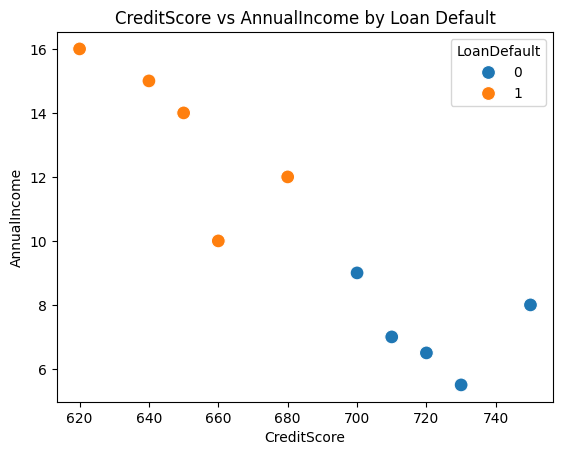

In [ ]:
# Scatter plot CreditScore vs AnnualIncome, colored by LoanDefault
sns.scatterplot(data=df, x="CreditScore", y="AnnualIncome", hue="LoanDefault", s=100)
plt.title("CreditScore vs AnnualIncome by Loan Default")
plt.show()

**3. Problem Statement**

Write a Python program to draw (visualize) the architecture of a Neural Network used to classify fraudulent and non-fraudulent credit card transactions.

Assume the fraud detection dataset contains the following input features:  

1. TransactionAmount
2. TransactionTime
3. MerchantCategory
4. CustomerAge
5. AccountBalance
6. NumberOfTransactionsToday
7. Fraud (0 = Genuine, 1 = Fraud)

**Ans:**  
> The neural network architecture for  fraud detection problem should contain six neurons in the input layer, for six input features.These inputs are passed through one or more hidden layers, where the number of neurons can vary depending on the model design. Hidden layers typically use the ReLU (Rectified Linear Unit) activation function to introduce non-linearity and help the network learn complex patterns in the data.  

>Since this is a binary classification **problem**, the output layer contains one neuron with a sigmoid activation function, which produces a probability value between 0 and 1 indicating the likelihood that a transaction is fraudulent.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Neural Network Architecture
layers = [6, 4, 3, 1]   # Input, Hidden1, Hidden2, Output

layer_names = [
    "Input Layer",
    "Hidden Layer 1",
    "Hidden Layer 2",
    "Output Layer"
]

In [ ]:
input_labels = [
    "TransactionAmount",
    "TransactionTime",
    "MerchantCategory",
    "CustomerAge",
    "AccountBalance",
    "TransactionsToday"
]

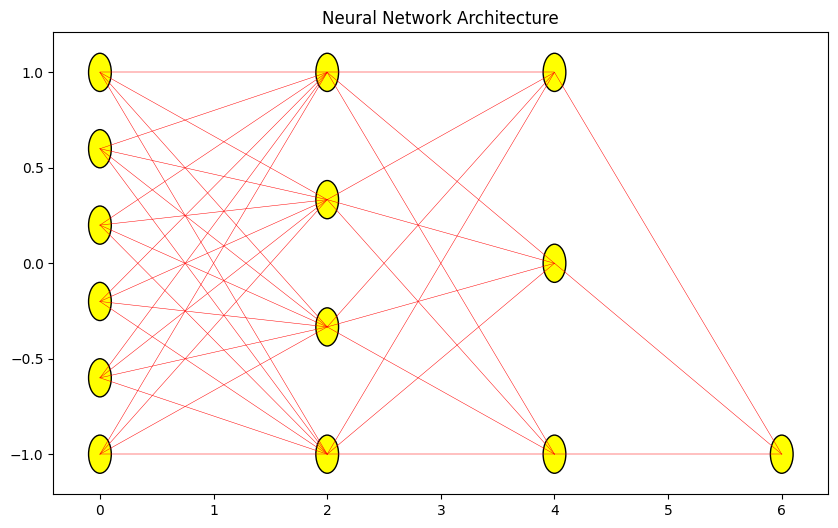

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
plt.title("Neural Network Architecture")

#
# Horizontal spacing
x_spacing = 2

# Loop through layers
for i, neurons in enumerate(layers):

    # Vertical spacing
    y_positions = np.linspace(-1, 1, neurons)

    for j, y in enumerate(y_positions):
        circle = plt.Circle((i*x_spacing, y), 0.1, color='yellow', ec='black')
        ax.add_patch(circle)

    if i > 0:
        prev_neurons = layers[i-1]
        prev_y = np.linspace(-1,1,prev_neurons)

        for y1 in prev_y:
            for y2 in y_positions:
                ax.plot([(i-1)*x_spacing, i*x_spacing], [y1, y2],
                        color="red", linewidth=0.35)

**4. Problem Statement**

Write a Python program to draw a 3D plot that visualizes the regression model for house price prediction using suitable Python-based 3D plotting libraries.

Assume the following features were used:
Area (sq ft)
Number of Bedrooms
House Price

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# Example data
area = [1000, 1200, 1500, 1800, 2000]
bedrooms = [2, 2, 3, 3, 4]
price = [200000, 220000, 300000, 350000, 400000]

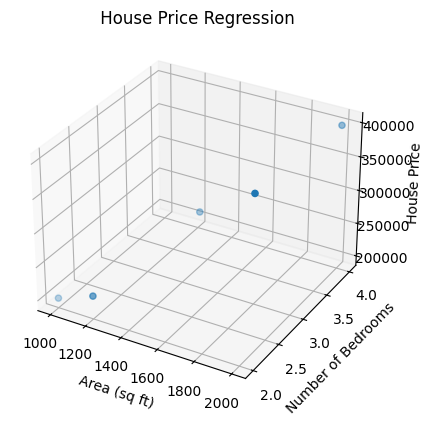

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(area, bedrooms, price)

ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Number of Bedrooms")
ax.set_zlabel("House Price")

plt.title(" House Price Regression")

plt.show()

**Problem 5- PROJECT + Presentation**

This is the case; you must develop using LLM and RAG. After submission you people must present to some of the panel members.  

**Use case**: “Policy & Claims Copilot” (Customer support + Claims pre-check)
**Goal** -
> 1. Help customers, agents, and claims teams get instant, consistent answers about:
>>1. what’s covered / not covered
>>2. limits & sub-limits
>>3. waiting periods
>>4. claim submission steps + timelines
documents needed

>2. do a pre-check of a claim scenario before submission.
This reduces call center load, speeds claim filing, and improves first-time-right submissions.

Why RAG is needed (vs plain LLM)
A plain LLM might “guess” policy terms. With RAG, the assistant:
retrieves the exact relevant clauses from the policy PDF
answers using only those clauses
quotes/links the source section/page (grounded response)

In [ ]:
!pip install -q langchain openai faiss-cpu pypdf tiktoken
!pip install -q langchain-community langchain-openai
!pip install langchain-text-splitters

In [ ]:
from google.colab import userdata
API_KEY = userdata.get('gemini_key')

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

file_name = "/content/drive/MyDrive/travel_policy.pdf"
loader = PyPDFLoader(file_name)
documents = loader.load()
# Split into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)
print("Total chunks created:", len(chunks))

Total chunks created: 44


In [ ]:
from langchain_community.vectorstores import FAISS

In [ ]:
!pip install --upgrade google-genai

In [ ]:
chunks_text = [doc.page_content for doc in chunks]

In [ ]:
from google import genai

client = genai.Client(api_key=API_KEY)

result = client.models.embed_content(
    model="gemini-embedding-001",
    contents=chunks_text#"What is the waiting period for maternity coverage?"
)

embedding = result.embeddings[0].values

In [ ]:
import numpy as np
import faiss

# Extract all embeddings from Gemini response
embeddings = [e.values for e in result.embeddings]

# Convert to numpy array (required for FAISS)
embedding_matrix = np.array(embeddings).astype("float32")

# Get embedding dimension
dimension = embedding_matrix.shape[1]

# Create FAISS index
index = faiss.IndexFlatL2(dimension)

# Add embeddings to index
index.add(embedding_matrix)

print("Total vectors stored in FAISS:", index.ntotal)

Total vectors stored in FAISS: 44


In [ ]:
import pickle
import faiss

# Save FAISS index
faiss.write_index(index, "policy_faiss_index")

# Save corresponding chunks
with open("policy_chunks.pkl", "wb") as f:
    pickle.dump(chunks_text, f)

print("FAISS index and chunks saved successfully.")

FAISS index and chunks saved successfully.


In [ ]:
import faiss
import pickle

# Load FAISS index
index = faiss.read_index("policy_faiss_index")

# Load text chunks
with open("policy_chunks.pkl", "rb") as f:
    chunks_text = pickle.load(f)

print("FAISS index loaded.")
print("Total stored vectors:", index.ntotal)
print("Total stored chunks:", len(chunks_text))

FAISS index loaded.
Total stored vectors: 44
Total stored chunks: 44


# RAG pipeline using google gemini

In [ ]:
def ask_policy_copilot(query, k=3):
    import numpy as np

    # Step 1 — Convert query to embedding
    response = client.models.embed_content(
        model="gemini-embedding-001",
        contents=query
    )

    query_embedding = np.array(response.embeddings[0].values).astype("float32")
    query_embedding = query_embedding.reshape(1, -1)

    # Step 2 — Search FAISS
    distances, indices = index.search(query_embedding, k)

    # Step 3 — Retrieve relevant chunks
    retrieved_chunks = [chunks_text[i] for i in indices[0]]

    # Step 4 — Prepare context
    context = "\n".join([f"Clause {i+1}: {c}" for i, c in enumerate(retrieved_chunks)])

    prompt = f"""
You are an transport policy assistant.

Answer the question ONLY using the policy clauses below.
If the answer is not in the policy text, say:
"The policy document does not contain this information."

Policy Clauses:
{context}

Question:
{query}

Answer:
"""

    # Step 5 — Generate response
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text

In [ ]:
while True:
    query = input("\nAsk Policy Copilot (type 'exit' to stop): ")

    if query.lower() == "exit":
        break

    response = ask_policy_copilot(query)
    print("\nCopilot:", response)


Ask Policy Copilot (type 'exit' to stop): what is the version?

Copilot: v1.0

Ask Policy Copilot (type 'exit' to stop): exit
